# MSE 5720 Assignment 1  
**Haichuan Zhang**  
📧 *hz738@cornell.edu*  

---

## Introduction  

This homework focuses on the calculation of various properties of **calcium titanate (CaTiO₃)** using *density functional theory (DFT)*.  
CaTiO₃ is a **perovskite-type oxide** with wide applications in electronic and energy-related fields, making it an interesting subject for first-principles study.  

- **Exercise 1**  
  The convergence behavior of the total energy with respect to **plane-wave cutoff energy** and **k-point sampling** is examined.  
  Since an infinite plane-wave basis set cannot be achieved in practice, a finite cutoff must be chosen.  
  A higher cutoff and denser k-point grid improve accuracy but also increase computational cost, so an optimal balance is desired.  

- **Exercise 2**  
  The equilibrium lattice constant of CaTiO₃ is obtained by **fitting the energy–volume curve** and through **structural optimization** using *Quantum ESPRESSO*.  
  The calculated results are then compared with benchmark values reported in the literature.  

- **Exercise 3**  
  The **bulk modulus** is determined from the **equation of state** by fitting the energy–volume relation.  
  The computed values are discussed in relation to the literature data, with attention to the accuracy of the fitting procedure.  

- **Exercise 4**  
  The effect of **different pseudopotentials** on the optimized lattice constant is evaluated and compared with the results from Exercise 2.  
  Since pseudopotential choice can influence the DFT results, experimental data are referenced to assess the reliability of the calculations.  


In [81]:
import os
import re
import requests
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

**Exercise 1a**

Perform a self-consistent field (SCF) calculation to determine the total energy of the system. Vary the plane-wave cutoff energy from 20 Ry to 100 Ry in steps of 10 Ry. The energy is considered well-converged when the difference in total energy between consecutive cutoff values is less than approximately 5 meV per formula unit. Present your results in a table and plot a graph of total energy versus cutoff energy.

In [82]:
base_path = "HW1/Q1/A"
cutoffs = list(range(20, 101, 10))  # 20, 30, ..., 100
print(cutoffs)
energies = []
energy_pattern = re.compile(r"! *total energy *= *([-+]?\d*\.\d+) Ry")

[20, 30, 40, 50, 60, 70, 80, 90, 100]


In [83]:
for cutoff in cutoffs:

    url = f"https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW1/Q1/A/cto_{cutoff}/CTO.out"
    
    response = requests.get(url)
    if response.status_code != 200:
        print(f"Failed to fetch {url}")
        energies.append(None)
        continue

    content = response.text
    match = energy_pattern.search(content)
    if match:
        energy = float(match.group(1))
        energies.append(energy)
        print(f"Cutoff {cutoff}: Energy = {energy} Ry")
    else:
        print(f"No energy found in {url}")
        energies.append(None)

Cutoff 20: Energy = -290.92254356 Ry
Cutoff 30: Energy = -291.66701012 Ry
Cutoff 40: Energy = -291.69406566 Ry
Cutoff 50: Energy = -291.69522418 Ry
Cutoff 60: Energy = -291.69650898 Ry
Cutoff 70: Energy = -291.69676334 Ry
Cutoff 80: Energy = -291.69726827 Ry
Cutoff 90: Energy = -291.6978959 Ry
Cutoff 100: Energy = -291.69824766 Ry


cutoffs: 9 [20, 30, 40, 50, 60, 70, 80, 90, 100]
energies: 9 [-290.92254356, -291.66701012, -291.69406566, -291.69522418, -291.69650898, -291.69676334, -291.69726827, -291.6978959, -291.69824766]


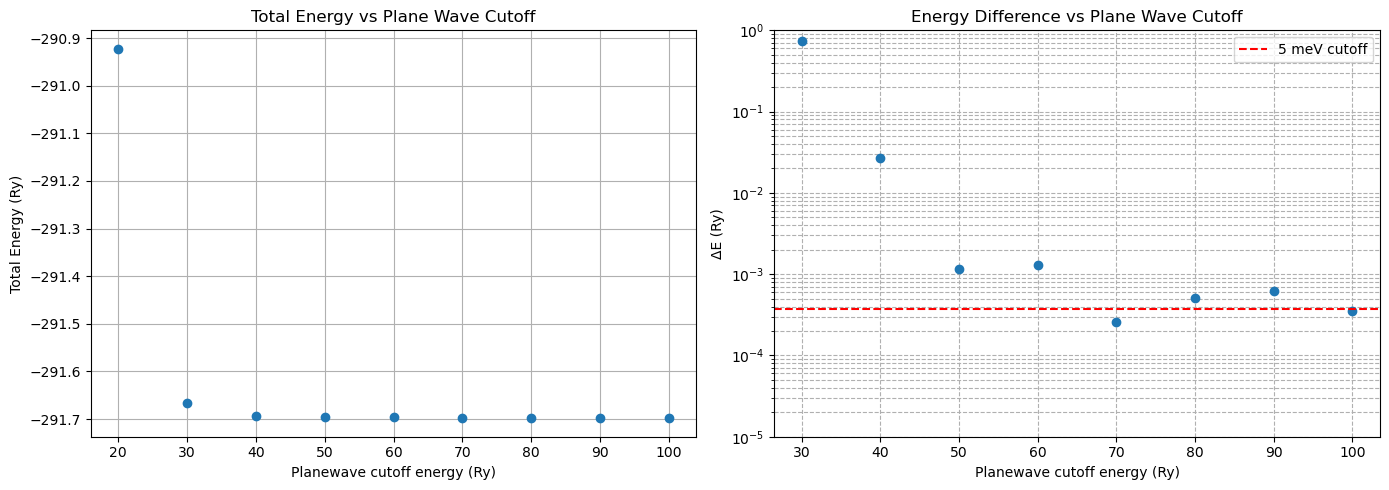

In [84]:
delta_energies = []
for i in range(len(energies)):
    if i == 0 or energies[i] is None or energies[i-1] is None:
        delta_energies.append(None)
    else:
        delta_energies.append(abs(energies[i] - energies[i-1]))
print("cutoffs:", len(cutoffs), cutoffs)
print("energies:", len(energies), energies)
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(cutoffs, energies, 'o')
axes[0].set_xlabel("Planewave cutoff energy (Ry)")
axes[0].set_ylabel("Total Energy (Ry)")
axes[0].set_title("Total Energy vs Plane Wave Cutoff")
axes[0].grid(True)

axes[1].plot(cutoffs, delta_energies, 'o')
axes[1].axhline(5e-3/13.6, color='r', linestyle='--', label="5 meV cutoff")  # Ry to meV by 13.6
axes[1].set_xlabel("Planewave cutoff energy (Ry)")
axes[1].set_ylabel("ΔE (Ry)")
axes[1].set_title("Energy Difference vs Plane Wave Cutoff")
axes[1].set_yscale('log')
axes[1].set_ylim(1e-5, 1)
axes[1].grid(True, which='both', ls='--')
axes[1].legend()

plt.tight_layout()
plt.show()

From the right sub figure it can be deduced that the planewave cutoff is 70 Ry.

**Exercise 1b**

Keep the calculation type as SCF and use the plane-wave cutoff energy determined as converged in Exercise 1a. Maintain all other parameters constant while investigating the convergence with respect to k-point sampling. Although there may be minor cross-effects between the plane-wave cutoff and k-point mesh, we assume these are negligible.

Compute the total energy using a series of M × M × M Monkhorst-Pack grids, where M = 2, 3, 4, 5, 6,7, 8, 9, 10, 11, 12. Record and tabulate the total energy for each grid density.

In [85]:
ks = list(range(2, 13))
energies = []
num_kpoints = []
print(ks)

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [86]:
energy_pattern = re.compile(r"! *total energy *= *([-+]?\d*\.\d+) Ry")
kpoint_pattern = re.compile(r"number of k points\s*=\s*(\d+)")

In [87]:
for k in ks:
    url = f"https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW1/Q1/B/cto_k{k}/CTO.out"
    response = requests.get(url)
    if response.status_code != 200:
        print(f"Failed to fetch {url}")
        energies.append(None)
        num_kpoints.append(None)
        continue

    content = response.text

    match_energy = energy_pattern.search(content)
    if match_energy:
        energy = float(match_energy.group(1))
    else:
        print(f"No energy found in {url}")
        energy = None
    energies.append(energy)

    match_k = kpoint_pattern.search(content)
    if match_k:
        nk = int(match_k.group(1))
    else:
        nk = None
    num_kpoints.append(nk)

    print(f"k={k}, number of k points={nk}, Energy={energy} Ry")

k=2, number of k points=4, Energy=-291.69522418 Ry
k=3, number of k points=4, Energy=-291.74232039 Ry
k=4, number of k points=10, Energy=-291.74866628 Ry
k=5, number of k points=10, Energy=-291.74976846 Ry
k=6, number of k points=20, Energy=-291.74996687 Ry
k=7, number of k points=20, Energy=-291.7500056 Ry
k=8, number of k points=35, Energy=-291.75001828 Ry
k=9, number of k points=35, Energy=-291.75002061 Ry
k=10, number of k points=56, Energy=-291.75002063 Ry
k=11, number of k points=56, Energy=-291.75002018 Ry
k=12, number of k points=84, Energy=-291.75002016 Ry


[None, 0.04709620999994968, 0.00634589000003416, 0.0011021799999753057, 0.0001984099999958744, 3.873000002840854e-05, 1.2679999997544655e-05, 2.3299999725168163e-06, 2.0000015865662135e-08, 4.500000159168849e-07, 1.9999959022243274e-08]


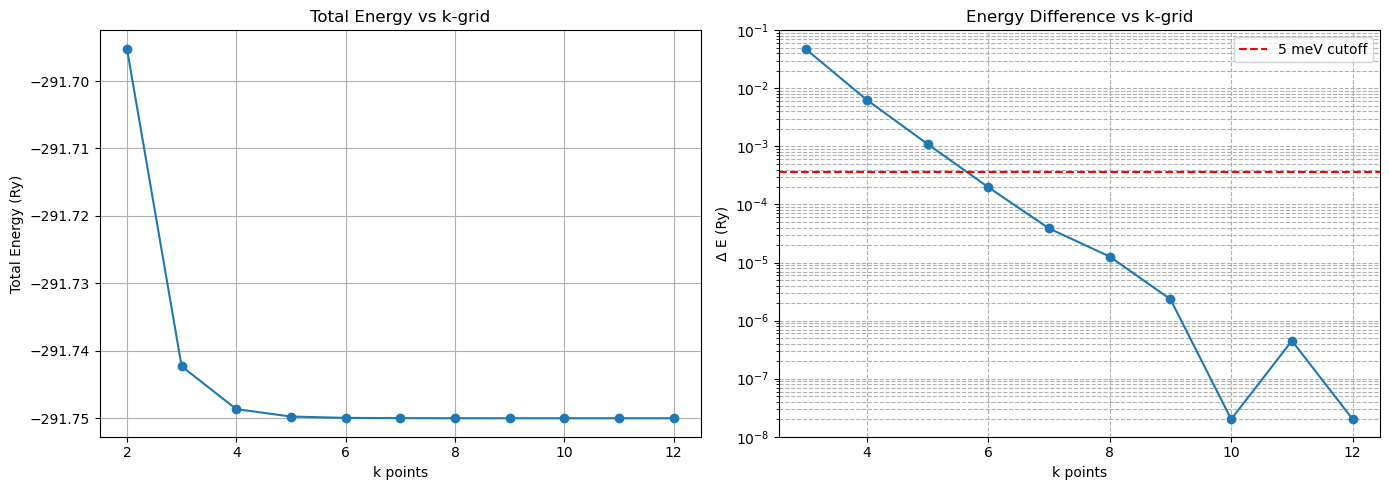

In [88]:
delta_energies = []
for i in range(len(energies)):
    if i == 0 or energies[i] is None or energies[i-1] is None:
        delta_energies.append(None)
    else:
        delta_energies.append(abs(energies[i] - energies[i-1]))
print(delta_energies)
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(ks, energies, marker='o')
axes[0].set_xlabel("k points")
axes[0].set_ylabel("Total Energy (Ry)")
axes[0].set_title("Total Energy vs k-grid")
axes[0].grid(True)

axes[1].plot(ks, delta_energies, marker='o')
axes[1].axhline(5e-3/13.6, color='r', linestyle='--', label="5 meV cutoff")
axes[1].set_xlabel("k points")
axes[1].set_ylabel("Δ E (Ry)")
axes[1].set_title("Energy Difference vs k-grid")
axes[1].set_yscale('log')
axes[1].set_ylim(1e-8, 1e-1)
axes[1].grid(True, which='both', ls='--')
axes[1].legend()

plt.tight_layout()
plt.show()

It can be deduced that the converged k point number is 6.

**Exercise 1c**

Displace one of the atoms in your unit cell by +0.05 in the z direction (fractional coordinates). Keeping other parameters fixed, calculate the force on the displaced atom as a function of planewave cutoff. A good value would be converged to within 10 meV/Ångstrom (convert this value to Ryd/bohr). Tabulate and make a graph of your results. Use a 
 k-point grid and energy cutoffs in the range 20 – 100 Ry. Repeat the calculations at a fixed planewave cutoff while varying the k-point grid.

In [89]:
cutoffs = list(range(20, 101, 10))  # 20, 30, ..., 120
forces = []

force_pattern = re.compile(r"Total force\s*=\s*([-+]?\d*\.\d+)")

for cutoff in cutoffs:
    url = f"https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW1/Q1/C/cto_dis_{cutoff}/CTO.out"
    response = requests.get(url)
    if response.status_code != 200:
        print(f"Failed to fetch {url}")
        forces.append(None)
        continue

    content = response.text

    match_force = force_pattern.search(content)
    if match_force:
        force = float(match_force.group(1))
        forces.append(force)
        print(f"Cutoff={cutoff}, Force={force}")
    else:
        print(f"No force found in {url}")
        forces.append(None)


Cutoff=20, Force=0.027056
Cutoff=30, Force=0.024704
Cutoff=40, Force=0.024702
Cutoff=50, Force=0.024698
Cutoff=60, Force=0.024711
Cutoff=70, Force=0.024715
Cutoff=80, Force=0.024716
Cutoff=90, Force=0.024719
Cutoff=100, Force=0.02472


[None, 0.002352, 1.9999999999985307e-06, 4.000000000000531e-06, 1.2999999999999123e-05, 4.000000000000531e-06, 9.999999999975306e-07, 3.0000000000030003e-06, 9.999999999975306e-07]


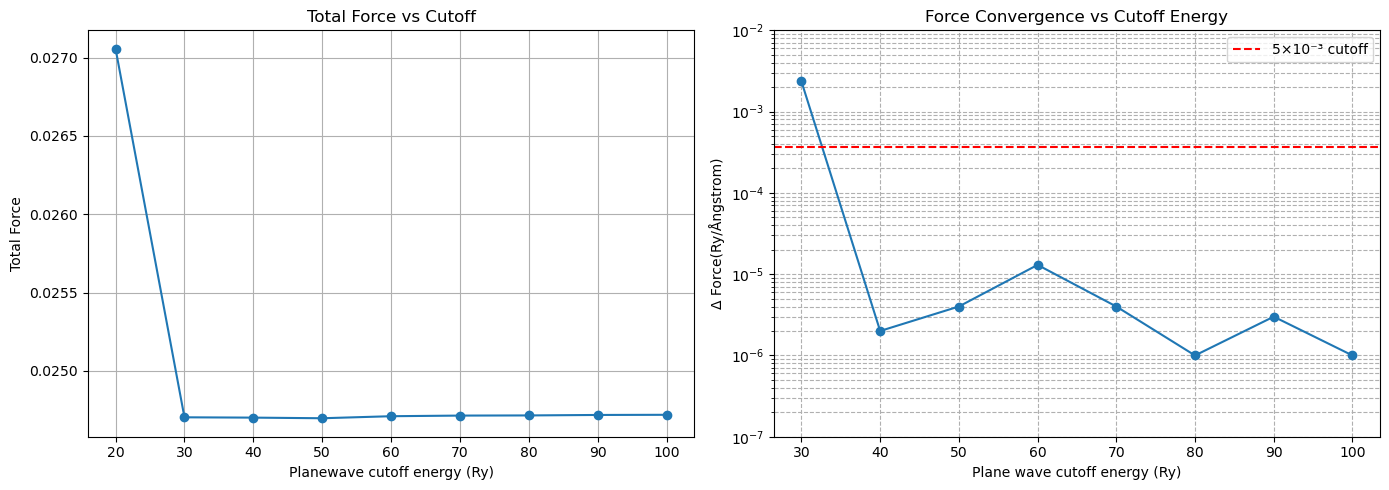

In [90]:
delta_forces = []
for i in range(len(forces)):
    if i == 0 or forces[i] is None or forces[i-1] is None:
        delta_forces.append(None)  
    else:
        delta_forces.append(abs(forces[i] - forces[i-1]))
print(delta_forces)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(cutoffs, forces, marker='o')
axes[0].set_xlabel("Planewave cutoff energy (Ry)")
axes[0].set_ylabel("Total Force")
axes[0].set_title("Total Force vs Cutoff")
axes[0].grid(True)

axes[1].plot(cutoffs, delta_forces, marker='o')
axes[1].axhline(5e-3/13.6, color='r', linestyle='--', label="5×10⁻³ cutoff")
axes[1].set_xlabel("Plane wave cutoff energy (Ry)")
axes[1].set_ylabel("Δ Force(Ry/Ångstrom)")
axes[1].set_title("Force Convergence vs Cutoff Energy")
axes[1].set_yscale('log')
axes[1].set_ylim(1e-7, 1e-2)
axes[1].grid(True, which='both', ls='--')
axes[1].legend()

plt.tight_layout()
plt.show()

In [91]:
ks_C = range(2, 13)

energies_C = []
num_kpoints_C = []

energy_pattern = re.compile(r'!.*total energy\s*=\s*(-?\d+\.\d+)')
kpoint_pattern = re.compile(r'number of k points=\s*(\d+)')

for k in ks_C:
    url = f"https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW1/Q1/C/CTO_DIS_K{k}/CTO_DIS_K{k}.out"
    response = requests.get(url)
    if response.status_code != 200:
        print(f"Failed to fetch {url}")
        energies_C.append(None)
        num_kpoints_C.append(None)
        continue

    content = response.text

    match_energy = energy_pattern.search(content)
    if match_energy:
        energy = float(match_energy.group(1))
    else:
        print(f"No energy found in {url}")
        energy = None
    energies_C.append(energy)

    match_k = kpoint_pattern.search(content)
    if match_k:
        nk = int(match_k.group(1))
    else:
        nk = None
    num_kpoints_C.append(nk)

    print(f"k={k}, number of k points={nk}, Energy={energy} Ry")

k=2, number of k points=6, Energy=-291.69837976 Ry
k=3, number of k points=6, Energy=-291.7452201 Ry
k=4, number of k points=18, Energy=-291.75156855 Ry
k=5, number of k points=18, Energy=-291.75264689 Ry
k=6, number of k points=40, Energy=-291.75284523 Ry
k=7, number of k points=40, Energy=-291.75288519 Ry
k=8, number of k points=75, Energy=-291.75289441 Ry
k=9, number of k points=75, Energy=-291.75289619 Ry
k=10, number of k points=126, Energy=-291.75289632 Ry
k=11, number of k points=126, Energy=-291.75289648 Ry
k=12, number of k points=196, Energy=-291.75289635 Ry


Delta energies (Ry): [None, 0.04684033999996018, 0.006348450000018602, 0.001078339999992295, 0.000198339999997188, 3.995999998096522e-05, 9.22000003811263e-06, 1.7799999909584585e-06, 1.2999998943996616e-07, 1.6000001323845936e-07, 1.2999998943996616e-07]


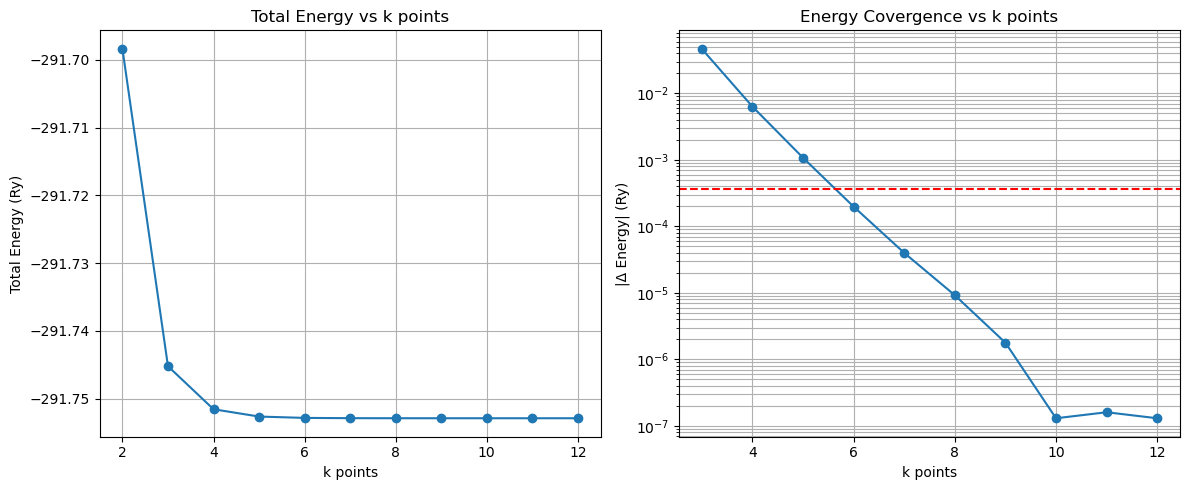

In [92]:
delta_energies_C = []
for i in range(len(energies_C)):
    if i == 0 or energies_C[i] is None or energies_C[i-1] is None:
        delta_energies_C.append(None)
    else:
        delta_energies_C.append(abs(energies_C[i] - energies_C[i-1]))

print("Delta energies (Ry):", delta_energies_C)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(ks_C, energies_C, marker='o')
axes[0].set_xlabel("k points")
axes[0].set_ylabel("Total Energy (Ry)")
axes[0].set_title("Total Energy vs k points")
axes[0].grid(True)

axes[1].plot(ks_C, delta_energies_C, marker='o')
axes[1].axhline(5e-3/13.6, color='r', linestyle='--', label="5×10⁻³ cutoff")
axes[1].set_xlabel("k points")
axes[1].set_ylabel("|Δ Energy| (Ry)")
axes[1].set_title("Energy Covergence vs k points")
axes[1].set_yscale("log")
axes[1].grid(True, which="both")

plt.tight_layout()
plt.show()

It can be deduced that the planewave cutoff is 40 Ry and the converged k point number is 6.

**Exercise 2: Optimization of lattice constants**

**Exercise 2a**

Keeping the calculation type as scf, vary the lattice constant **±5%**
 from the initial value in the input file (you can decide on the increments but ideally you should have approximately 10-12 data points in total). Use the converged plane wave cutoff and k-point mesh from Exercise 1C.

Index 1: alat=6.9894 a.u., Energy=-291.74131729 Ry
Index 2: alat=7.0563 a.u., Energy=-291.75311849 Ry
Index 3: alat=7.1232 a.u., Energy=-291.76002734 Ry
Index 4: alat=7.1901 a.u., Energy=-291.76247586 Ry
Index 5: alat=7.2570 a.u., Energy=-291.76084245 Ry
Index 6: alat=7.3239 a.u., Energy=-291.75549332 Ry
Index 7: alat=7.3907 a.u., Energy=-291.74674752 Ry
Index 8: alat=7.4576 a.u., Energy=-291.73493145 Ry
Index 9: alat=7.5245 a.u., Energy=-291.72031397 Ry
Index 10: alat=7.5914 a.u., Energy=-291.70317201 Ry
Index 11: alat=7.6583 a.u., Energy=-291.68374431 Ry
Index 12: alat=7.7252 a.u., Energy=-291.66224787 Ry


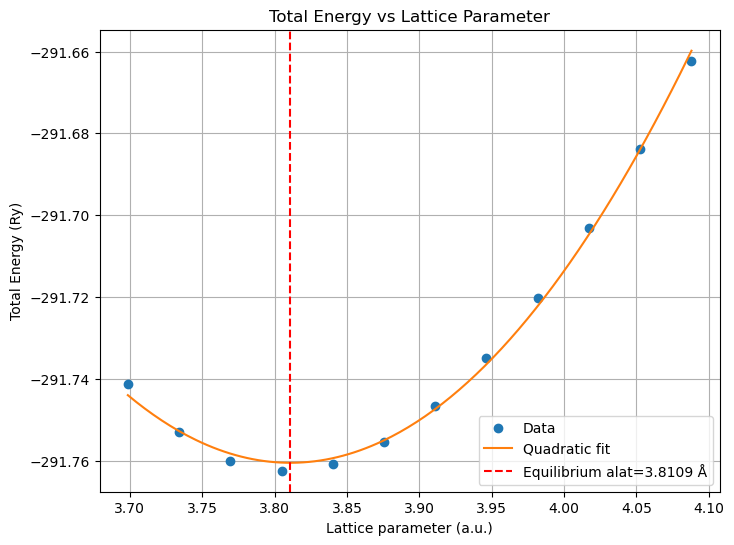

Quadratic fit coefficients [a, b, c]: [   1.31202278   -9.99995481 -272.70616195]
Equilibrium lattice parameter (alat) = 3.810892 a.u.
Minimum energy = -291.760537 Ry


In [93]:
import requests
import re
import matplotlib.pyplot as plt
import numpy as np

base_url = "https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW1/Q2/A/cto_{}/CTO_CELLDM_{}.out"
indices = range(1, 13)  # 1-12

alat_pattern = re.compile(r"lattice parameter \(alat\)\s*=\s*([\d\.]+)\s*a\.u\.")
energy_pattern = re.compile(r"! *total energy *= *([-+]?\d+\.\d+) Ry")

alats = []
energies = []

for i in indices:
    url = base_url.format(i, i)
    r = requests.get(url)
    if r.status_code != 200:
        print(f"Failed to fetch {url}")
        continue

    content = r.text
    alat_match = alat_pattern.search(content)
    energy_match = energy_pattern.search(content)

    if alat_match and energy_match:
        alats.append(float(alat_match.group(1)))
        energies.append(float(energy_match.group(1)))
        print(f"Index {i}: alat={alat_match.group(1)} a.u., Energy={energy_match.group(1)} Ry")
    else:
        print(f"No data found in {url}")

alats = np.array(alats)*0.529177
energies = np.array(energies)


coeffs = np.polyfit(alats, energies, 2)
poly = np.poly1d(coeffs)

alat_fit = np.linspace(min(alats), max(alats), 200)
energy_fit = poly(alat_fit)

alat_min = -coeffs[1] / (2 * coeffs[0])
energy_min = poly(alat_min)

plt.figure(figsize=(8,6))
plt.plot(alats, energies, 'o', label="Data")
plt.plot(alat_fit, energy_fit, '-', label="Quadratic fit")
plt.axvline(alat_min, color='r', linestyle='--', label=f"Equilibrium alat={alat_min:.4f} Å")
plt.xlabel("Lattice parameter (a.u.)")
plt.ylabel("Total Energy (Ry)")
plt.title("Total Energy vs Lattice Parameter")
plt.grid(True)
plt.legend()
plt.show()

print("Quadratic fit coefficients [a, b, c]:", coeffs)
print(f"Equilibrium lattice parameter (alat) = {alat_min:.6f} a.u.")
print(f"Minimum energy = {energy_min:.6f} Ry")


Index 1: alat=6.9894 a.u., Energy=-291.74283819 Ry
Index 2: alat=7.0563 a.u., Energy=-291.75462959 Ry
Index 3: alat=7.1232 a.u., Energy=-291.76153837 Ry
Index 4: alat=7.1901 a.u., Energy=-291.76396901 Ry
Index 5: alat=7.2570 a.u., Energy=-291.76232815 Ry
Index 6: alat=7.3239 a.u., Energy=-291.75696703 Ry
Index 7: alat=7.3907 a.u., Energy=-291.74821885 Ry
Index 8: alat=7.4576 a.u., Energy=-291.73640016 Ry
Index 9: alat=7.5245 a.u., Energy=-291.72177862 Ry
Index 10: alat=7.5914 a.u., Energy=-291.70463463 Ry
Index 11: alat=7.6583 a.u., Energy=-291.68519991 Ry
Index 12: alat=7.7252 a.u., Energy=-291.66370411 Ry


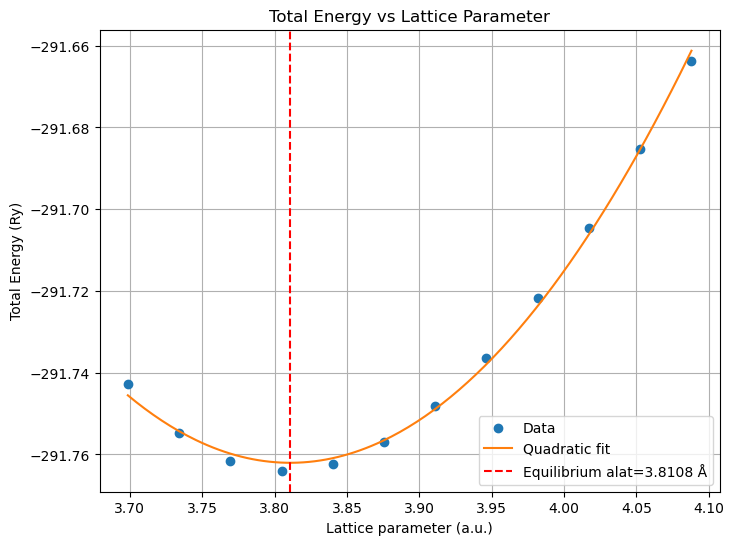

Quadratic fit coefficients [a, b, c]: [   1.31165465   -9.99691589 -272.71388907]
Equilibrium lattice parameter (alat) = 3.810803 a.u.
Minimum energy = -291.762029 Ry


In [94]:
base_url = "https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW1/Q2/A1/cto_{}/CTO_CELLDM_{}.out"
indices = range(1, 13)  # 1-12

alat_pattern = re.compile(r"lattice parameter \(alat\)\s*=\s*([\d\.]+)\s*a\.u\.")
energy_pattern = re.compile(r"! *total energy *= *([-+]?\d+\.\d+) Ry")

alats = []
energies = []

for i in indices:
    url = base_url.format(i, i)
    r = requests.get(url)
    if r.status_code != 200:
        print(f"Failed to fetch {url}")
        continue

    content = r.text
    alat_match = alat_pattern.search(content)
    energy_match = energy_pattern.search(content)

    if alat_match and energy_match:
        alats.append(float(alat_match.group(1)))
        energies.append(float(energy_match.group(1)))
        print(f"Index {i}: alat={alat_match.group(1)} a.u., Energy={energy_match.group(1)} Ry")
    else:
        print(f"No data found in {url}")

alats = np.array(alats)*0.529177
energies = np.array(energies)

coeffs = np.polyfit(alats, energies, 2)
poly = np.poly1d(coeffs)

alat_fit = np.linspace(min(alats), max(alats), 200)
energy_fit = poly(alat_fit)

alat_min = -coeffs[1] / (2 * coeffs[0])
energy_min = poly(alat_min)

plt.figure(figsize=(8,6))
plt.plot(alats, energies, 'o', label="Data")
plt.plot(alat_fit, energy_fit, '-', label="Quadratic fit")
plt.axvline(alat_min, color='r', linestyle='--', label=f"Equilibrium alat={alat_min:.4f} Å")
plt.xlabel("Lattice parameter (a.u.)")
plt.ylabel("Total Energy (Ry)")
plt.title("Total Energy vs Lattice Parameter")
plt.grid(True)
plt.legend()
plt.show()

print("Quadratic fit coefficients [a, b, c]:", coeffs)
print(f"Equilibrium lattice parameter (alat) = {alat_min:.6f} a.u.")
print(f"Minimum energy = {energy_min:.6f} Ry")


**Exercise 2b**

Change the calculation type to vc-relax and add the following lines to your input file. The ion dynamics and cell dynamics keywords select the optimization algorithm (in this case, Broyden-Fletcher-Goldfarb-Shanno), while press=0.d0 is the target pressure on the cell in KBar, i.e. the calculation will stop when the pressure on the unit cell is 0 KBar (actually, less than 0.5 KBar). Two other criteria must be satisfied.

In [95]:
url = "https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW1/Q2/B/cto_vc_relax/CTO_vc.out"

response = requests.get(url)
if response.status_code != 200:
    raise RuntimeError(f"Failed to fetch {url}")

text = response.text

alat_match = re.search(r"CELL_PARAMETERS\s*\(alat=\s*([\d.]+)\)", text)
if not alat_match:
    raise ValueError("Could not find CELL_PARAMETERS with alat")

alat_bohr = float(alat_match.group(1))

cell_block_match = re.search(r"CELL_PARAMETERS.*?\n(.*?)\n(.*?)\n(.*?)\n", text, re.S)
if not cell_block_match:
    raise ValueError("Could not extract CELL_PARAMETERS block")

cell_matrix = []
for i in range(1, 4):
    row = list(map(float, cell_block_match.group(i).split()))
    cell_matrix.append(row)
cell_matrix = np.array(cell_matrix)

cell_matrix_bohr = cell_matrix * alat_bohr

lattice_const_bohr = np.linalg.norm(cell_matrix_bohr[0])
lattice_const_ang = lattice_const_bohr * 0.529177  # Bohr to Angstrom

print(f"Optimized lattice constant: {lattice_const_ang:.4f} Å")

Optimized lattice constant: 3.8143 Å


**Exercise 2c**

The optimized lattice constant is **3.8143 Å**
the fitted lattice constant s **3.8109 Å**
If taking the value from Springer Materials [1] as a benchmark value, which is **3.905 Å**, the optimized lattice constant has a relative error of **2.41%**, the fitted lattice constant has a relative error of **2.32%**.

**Exercise 3: Optimization of lattice constants**

**Exercise 3a**

Calculate the bulk modulus of your material (in GPa) at its equilibrium lattice parameter

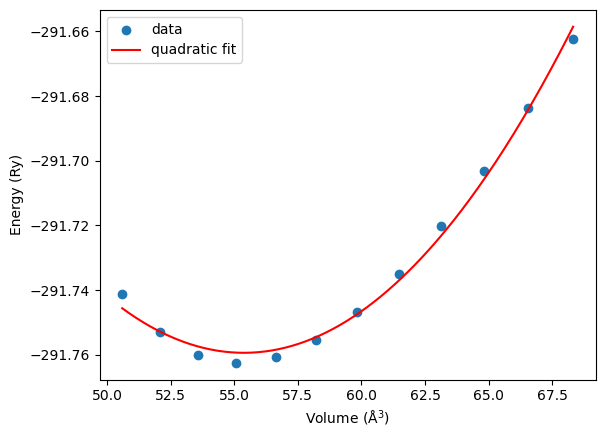

Bulk modulus (GPa): 144.65374096732072


In [96]:
bohr_to_angstrom = 0.529177

def fetch_alat_energy(i):
    url = f"https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW1/Q2/A/cto_{i}/CTO_CELLDM_{i}.out"
    r = requests.get(url)
    if r.status_code != 200:
        return None, None
    text = r.text
    alat_match = re.search(r"lattice parameter \(alat\)\s*=\s*([\d\.]+)", text)
    energy_match = re.search(r"!.*total energy\s*=\s*([-.\d]+)", text)
    if alat_match and energy_match:
        alat_bohr = float(alat_match.group(1))
        alat_angstrom = alat_bohr * bohr_to_angstrom
        volume = alat_angstrom**3
        energy = float(energy_match.group(1))
        return volume, energy
    return None, None

volumes, energies = [], []
for i in range(1, 21):
    v, e = fetch_alat_energy(i)
    if v is not None and e is not None:
        volumes.append(v)
        energies.append(e)

volumes = np.array(volumes)
energies = np.array(energies)

def quadratic(V, a, b, c):
    return a*V**2 + b*V + c

popt, _ = curve_fit(quadratic, volumes, energies)
a, b, c = popt
V0 = volumes[np.argmin(energies)]
E0 = min(energies)

Ry_to_J = 2.1798723611035e-18
A3_to_m3 = 1e-30
d2E_dV2 = 2*a
B_GPa = V0 * d2E_dV2 * Ry_to_J / A3_to_m3 / 1e9

V_fit = np.linspace(min(volumes), max(volumes), 200)
E_fit = quadratic(V_fit, *popt)

plt.scatter(volumes, energies, label="data")
plt.plot(V_fit, E_fit, 'r-', label="quadratic fit")
plt.xlabel("Volume ($\\mathrm{Å}^3$)")
plt.ylabel("Energy (Ry)")
plt.legend()
plt.show()

print("Bulk modulus (GPa):", B_GPa)


According to Tian et al, [1], the bulk modulus of BAs is 175 GPa, indicating the DFT computed bulk modulus has the relative error of 17%.

We consider that the previous choice of lattice parameters may have affected the curve fitting. Therefore, we re-sampled 20 data points within a symmetric range of ±5%. The resulting fit shows a slight deviation from a simple quadratic curve, but the fitted curve is closer to the experimental values.

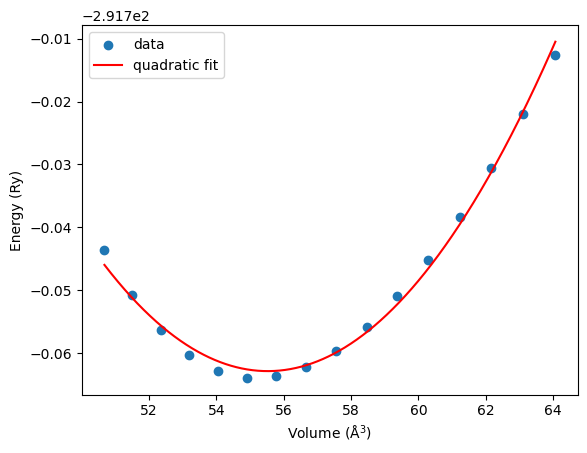

Bulk modulus (GPa): 171.78150983915617


In [97]:
bohr_to_angstrom = 0.529177

def fetch_alat_energy(i):
    url = f"https://github.com/chemerzhc/Cornell-MSE5720-Assignment/blob/main/HW1/Q3/cto_{i}/CTO_module_{i}.out"
    r = requests.get(url)
    if r.status_code != 200:
        return None, None
    text = r.text
    alat_match = re.search(r"lattice parameter \(alat\)\s*=\s*([\d\.]+)", text)
    energy_match = re.search(r"!.*total energy\s*=\s*([-.\d]+)", text)
    if alat_match and energy_match:
        alat_bohr = float(alat_match.group(1))
        alat_angstrom = alat_bohr * bohr_to_angstrom
        volume = alat_angstrom**3
        energy = float(energy_match.group(1))
        return volume, energy
    return None, None

volumes, energies = [], []
for i in range(5, 21):
    v, e = fetch_alat_energy(i)
    if v is not None and e is not None:
        volumes.append(v)
        energies.append(e)

volumes = np.array(volumes)
energies = np.array(energies)

def quadratic(V, a, b, c):
    return a*V**2 + b*V + c

popt, _ = curve_fit(quadratic, volumes, energies)
a, b, c = popt
V0 = volumes[np.argmin(energies)]
E0 = min(energies)

Ry_to_J = 2.1798723611035e-18
A3_to_m3 = 1e-30
d2E_dV2 = 2*a
B_GPa = V0 * d2E_dV2 * Ry_to_J / A3_to_m3 / 1e9

V_fit = np.linspace(min(volumes), max(volumes), 1000)
E_fit = quadratic(V_fit, *popt)

plt.scatter(volumes, energies, label="data")
plt.plot(V_fit, E_fit, 'r-', label="quadratic fit")
plt.xlabel("Volume ($\\mathrm{Å}^3$)")
plt.ylabel("Energy (Ry)")
plt.legend()
plt.show()

print("Bulk modulus (GPa):", B_GPa)


**Exercise 4: Effect of different XC-functionals on lattice parameter**

In the input file, modify the pseudopotential information to use PBE pseudopotentials Espresso determines which XC-functional to use from the pseudopotential files. Calculate the equilibrium lattice parameter using Espresso’s optimization algorithm.

The **PBE** calculation results are in better agreement with the experimental values. The computed lattice constant is **3.891 Å**, corresponding to an error of **0.36%**. This result is consistent with values reported in other literature.

Compared with **LDA, PBE** generally provides a more accurate description of lattice constants for perovskite oxides like CaTiO₃. LDA tends to underestimate lattice parameters due to its overbinding tendency, which results in smaller predicted volumes. In contrast, the **PBE** functional, as a **generalized gradient approximation (GGA)**, mitigates this systematic underestimation and more accurately reproduces the equilibrium geometry of the CaTiO₃ structure.

**Exercise 5: Linux and the supercomputing environment**

Draw a block diagram that visually represents the relationships between the following components of the Linux OS and the Stampede3 **[7]** supercomputing environment: kernel, shell, login node, compute notes, batch queue, your laptop.

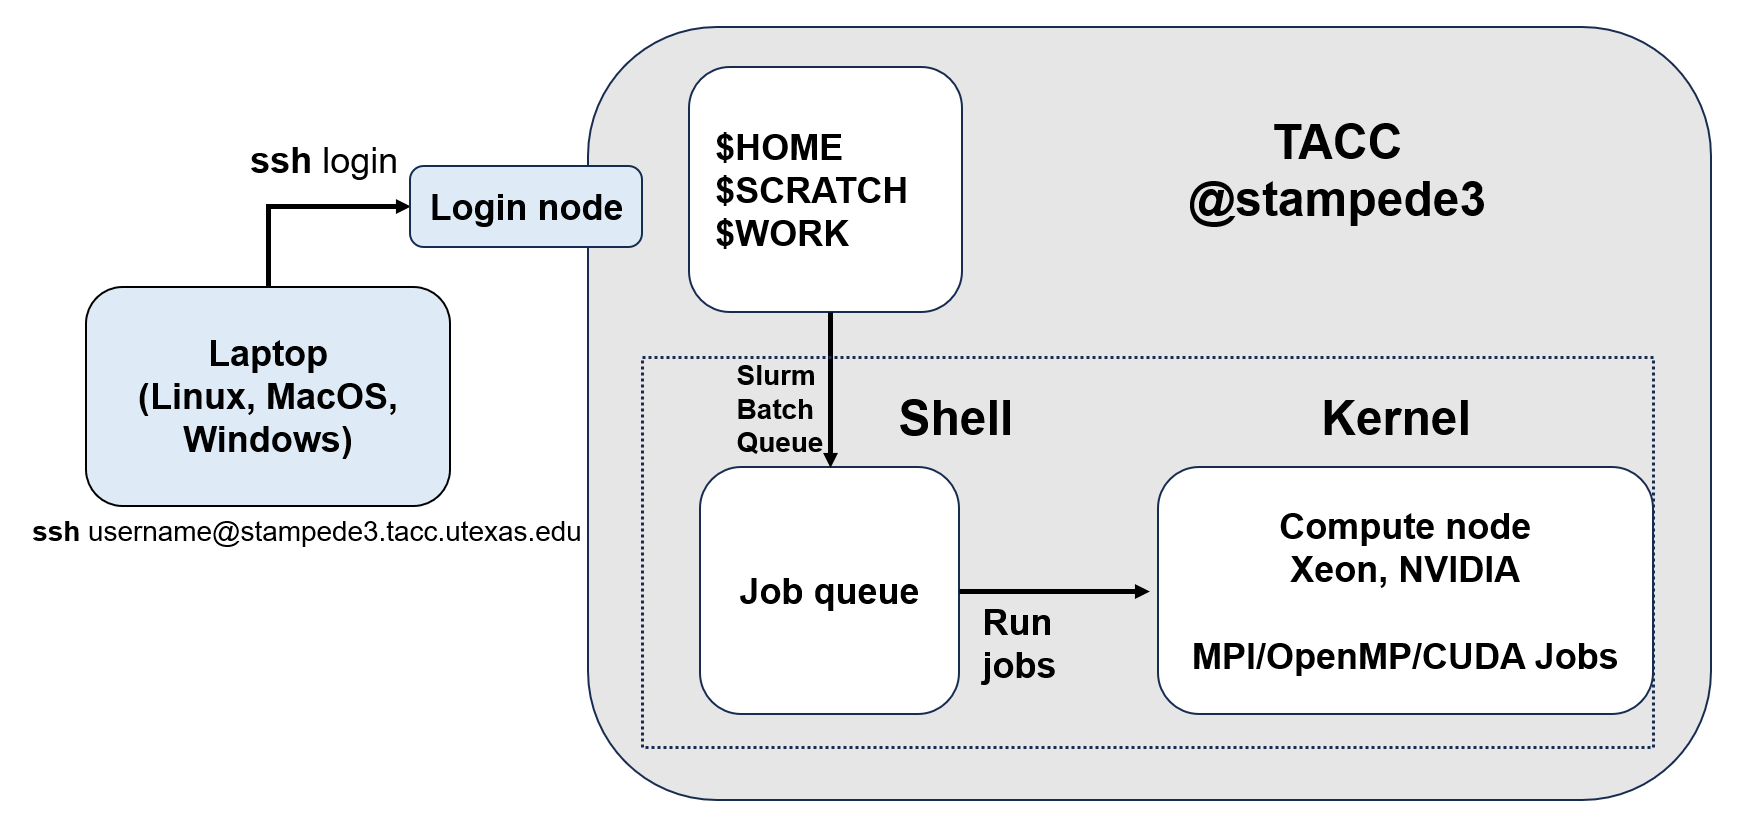

**Reference**

[1]Boudali, A., Abada, A., Khodja, M. D., Amrani, B., Amara, K., Khodja, F. D., & Elias, A. (2010). Calculation of structural, elastic, electronic, and thermal properties of orthorhombic CaTiO3. Physica B: Condensed Matter, 405(18), 3879-3884.

[2]Saha, S., Sinha, T. P., & Mookerjee, A. (2000). First principles study of electronic structure and optical properties of CaTiO3. The European Physical Journal B-Condensed Matter and Complex Systems, 18(2), 207-214.

[3]Shalkova, E. K., Bajkov, Y. M., Melekh, B. T., Perevalova, T. A., & Filin, Y. N. (1990). Hydrogen in complex oxides with perovskite structure CaTiO3, SrTiO3, BaTiO3, BaCeO3.

[4]Tariq, S., Ahmed, A., Saad, S., & Tariq, S. (2015). Structural, electronic and elastic properties of the cubic CaTiO3 under pressure: A DFT study. Aip Advances, 5(7).

[5]Ross, N. L., & Angel, R. J. (1999). Compression of CaTiO3 and CaGeO3 perovskites. American Mineralogist, 84(3), 277-281.

[6]Sinelnikov, Y. D., Chen, G., & Liebermann, R. C. (1998). Elasticity of CaTiO3–CaSiO3 perovskites. Physics and Chemistry of Minerals, 25(7), 515-521.

[7]Minyard, T. K. (2023). Category I: Stampede3-Modernizing and Evolving The Largest ACCESS Compute Resource. NSF Award Number 2320757. Directorate for Computer and Information Science and Engineering, 23(2320757), 20757.
